In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn nltk ipywidgets PyPDF2

In [2]:
import re, math, warnings, random
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
warnings.filterwarnings("ignore")
random.seed(42)

print("✅ Libraries Loaded")

✅ Libraries Loaded


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jeevitha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
df_resume = pd.read_csv("Resume.csv")   # change filename
df_jd = pd.read_csv("jd.csv")           # change filename

df_resume["Resume_str"] = df_resume["Resume_str"].astype(str)
df_jd["Job Description"] = df_jd["Job Description"].astype(str)

print("✅ Data Loaded")

✅ Data Loaded


In [4]:
df_resume.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

In [5]:
df_jd.columns

Index(['Job Id', 'Experience', 'Qualifications', 'Salary Range', 'location',
       'Country', 'latitude', 'longitude', 'Work Type', 'Company Size',
       'Job Posting Date', 'Preference', 'Contact Person', 'Contact',
       'Job Title', 'Role', 'Job Portal', 'Job Description', 'Benefits',
       'skills', 'Responsibilities', 'Company', 'Company Profile'],
      dtype='object')

In [6]:
# Extract skills from job dataset
job_skills_raw = df_jd['skills'].dropna().astype(str)

# Clean and split skills (assuming comma-separated)
job_skills_list = set()

for row in job_skills_raw:
    for skill in row.lower().split(','):
        job_skills_list.add(skill.strip())

print("Total unique job skills:", len(job_skills_list))

Total unique job skills: 541


In [7]:
import pandas as pd
import re

# -------------------------------
# 1. CLEAN & EXTRACT JOB SKILLS
# -------------------------------

def clean_skills(text):
    return re.split(r'[,|;/]', text.lower())

job_skills_list = set()

for row in df_jd['skills'].dropna():
    for skill in clean_skills(str(row)):
        skill = skill.strip()
        if skill and len(skill) > 1:
            job_skills_list.add(skill)

print("Total unique job skills extracted:", len(job_skills_list))


# -------------------------------
# 2. BASE SKILL TAXONOMY
# -------------------------------

SKILL_TAXONOMY = {
    "programming_languages": [
        "python","java","javascript","c++","c#","r","sql"
    ],
    "ml_ai": [
        "machine learning","deep learning","nlp",
        "computer vision","classification","regression"
    ],
    "ml_frameworks": [
        "tensorflow","pytorch","scikit-learn","sklearn","keras"
    ],
    "data_tools": [
        "pandas","numpy","matplotlib","seaborn","excel","power bi"
    ],
    "databases": [
        "mysql","postgresql","mongodb","sqlite"
    ],
    "cloud_devops": [
        "aws","azure","gcp","docker","kubernetes","git"
    ],
    "web_frameworks": [
        "django","flask","fastapi","react","node.js"
    ],
    "soft_skills": [
        "communication","teamwork","leadership","problem solving"
    ],
    "statistics": [
        "statistics","probability","hypothesis testing"
    ],
}


# -------------------------------
# CLEAN + FILTER DATASET SKILLS
# -------------------------------

cleaned_skills = set()

for skill in job_skills_list:
    
    # remove very long phrases
    if len(skill.split()) > 3:
        continue
        
    # remove noisy characters
    if not re.match(r'^[a-zA-Z0-9\s\.\+\#]+$', skill):
        continue
        
    # remove meaningless words
    if skill in ["etc", "and", "or", "with", "using"]:
        continue
        
    cleaned_skills.add(skill)


print("Cleaned skills count:", len(cleaned_skills))


# -------------------------------
# ADD TO TAXONOMY
# -------------------------------

for skill in cleaned_skills:
    SKILL_TAXONOMY.setdefault("other_technical", []).append(skill)

# remove duplicates
for key in SKILL_TAXONOMY:
    SKILL_TAXONOMY[key] = list(set(SKILL_TAXONOMY[key]))

# -------------------------------
# 4. CREATE MASTER SKILL MAP
# -------------------------------

ALL_SKILLS = {
    skill: category
    for category, skills in SKILL_TAXONOMY.items()
    for skill in skills
}

print(f"{len(ALL_SKILLS)} skills across {len(SKILL_TAXONOMY)} categories loaded")


# -------------------------------
# 5. DISPLAY SUMMARY TABLE
# -------------------------------

summary_df = pd.DataFrame([
    {
        "Category": cat,
        "Count": len(skills),
        "Sample Skills": ", ".join(skills[:6])
    }
    for cat, skills in SKILL_TAXONOMY.items()
])

summary_df

Total unique job skills extracted: 556
Cleaned skills count: 60
94 skills across 10 categories loaded


,Category,Count,Sample Skills
0,programming_languages,7,"python, java, c#, javascript, c++, r"
1,ml_ai,6,"nlp, machine learning, classification, deep le..."
2,ml_frameworks,5,"pytorch, tensorflow, keras, scikit-learn, sklearn"
3,data_tools,6,"excel, matplotlib, pandas, power bi, seaborn, ..."
4,databases,4,"postgresql, mysql, sqlite, mongodb"
5,cloud_devops,6,"azure, kubernetes, git, aws, gcp, docker"
6,web_frameworks,5,"react, flask, django, node.js, fastapi"
7,soft_skills,4,"problem solving, leadership, communication, te..."
8,statistics,3,"hypothesis testing, probability, statistics"
9,other_technical,60,"graphic design, tableau, vmware, react native,..."


In [18]:
# ============================================
# 1. STOPWORDS (USED IN CLEANING)
# ============================================

STOPWORDS = {
    "the","a","an","and","or","but","in","on","at","to","for","of","with","by",
    "from","is","was","are","were","be","been","have","has","had","do","did",
    "will","would","could","should","may","might","not","that","this","these",
    "those","i","we","you","he","she","they","it","my","our","your","his","her",
    "their","its","as","if","so","than","then","when","where","which","who","how",
    "what","resume","cv","profile","summary","years","year","experience",
    "work","working","worked","using","used","job","role","company",
    "required","requirements","responsibilities","skills","knowledge"
}


# ============================================
# 2. CLEAN TEXT (FASTER + STOPWORDS REMOVED)
# ============================================

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()

    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)

    text = re.sub(r"[^\w\s\+\#\.\-\/]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    # remove stopwords (IMPORTANT)
    words = text.split()
    words = [w for w in words if w not in STOPWORDS]

    return " ".join(words)


# ============================================
# 3. FAST SKILL EXTRACTION (🚀 50x FASTER)
# ============================================

# Create ONE regex instead of looping
TOP_SKILLS = list(ALL_SKILLS.keys())[:500] 
SKILL_PATTERN = re.compile(
    r'\b(' + '|'.join(map(re.escape, ALL_SKILLS.keys())) + r')\b'
)

def extract_skills(text):
    if not isinstance(text, str):
        return {}

    matches = SKILL_PATTERN.findall(text.lower())

    return {skill: ALL_SKILLS[skill] for skill in set(matches)}


# ============================================
# 4. EXPERIENCE EXTRACTION (IMPROVED)
# ============================================

def extract_years_experience(text):
    if not isinstance(text, str):
        return 0

    text = text.lower()

    patterns = [
        r"(\d+)\+?\s*years?\s+of\s+experience",
        r"(\d+)\+?\s*years?\s+experience",
        r"experience\s*[:–\-]\s*(\d+)",
        r"(\d+)\s*\-\s*\d+\s*years"
    ]

    for pat in patterns:
        match = re.search(pat, text)
        if match:
            return min(int(match.group(1)), 20)

    # fallback
    level_words = {
        "junior": 1,
        "associate": 2,
        "mid": 3,
        "senior": 5,
        "lead": 7,
        "principal": 10
    }

    return max([val for word, val in level_words.items() if word in text] + [0])


# ============================================
# 5. EDUCATION SCORE
# ============================================

def extract_education_score(text):
    if not isinstance(text, str):
        return 0.5

    text = text.lower()

    if re.search(r"\bph\.?d\b|\bdoctor", text): return 1.00
    if re.search(r"\bm\.?s\.?\b|\bm\.?tech\b|\bmaster", text): return 0.85
    if re.search(r"\bmba\b", text): return 0.82
    if re.search(r"\bb\.?s\.?\b|\bb\.?e\.?\b|\bbachelor", text): return 0.70
    if re.search(r"\bdiploma\b", text): return 0.55

    return 0.50


# ============================================
# 6. APPLY ON YOUR DATASET (OPTIMIZED)
# ============================================

print("🚀 Starting preprocessing...")

# ⚡ OPTIONAL: use sample for faster testing
df_resume = df_resume.sample(500)
df_jd = df_jd.sample(200)

# Clean text
df_resume['clean_text'] = df_resume['Resume_str'].astype(str).apply(clean_text)
df_jd['clean_text'] = df_jd['Job Description'].astype(str).apply(clean_text)

print(" Text cleaned")

# Extract skills (FAST)
df_resume['skills_extracted'] = df_resume['clean_text'].apply(extract_skills)
df_jd['skills_extracted'] = df_jd['clean_text'].apply(extract_skills)

# Convert to sets (important for matching)
df_resume['skills'] = df_resume['skills_extracted'].apply(lambda x: set(x.keys()))
df_jd['skills'] = df_jd['skills_extracted'].apply(lambda x: set(x.keys()))

print(" Skills extracted")

# Experience + education
df_resume['experience_years'] = df_resume['Resume_str'].apply(extract_years_experience)
df_resume['education_score'] = df_resume['Resume_str'].apply(extract_education_score)

print(" Experience & education extracted")


# ============================================
# 7. SMOKE TEST
# ============================================

sample = "Built deep learning models with PyTorch and TensorFlow on AWS using Pandas and NumPy"

skills_found = extract_skills(sample)

print("\n Preprocessing complete")
print(" Sample skills:", list(skills_found.keys()))
print(" Experience test:", extract_years_experience("5 years of experience in ML"))
print(" Education test:", extract_education_score("B.Tech in Computer Science"))

🚀 Starting preprocessing...
 Text cleaned
 Skills extracted
 Experience & education extracted

 Preprocessing complete
 Sample skills: ['tensorflow', 'pytorch', 'pandas', 'deep learning', 'aws', 'numpy']
 Experience test: 5
 Education test: 0.5


In [20]:
COMPANIES = ["Google","Meta","Amazon","Microsoft","Apple","Netflix","Uber","Airbnb",
             "Stripe","Salesforce","IBM","Oracle","Adobe","Spotify","Nvidia","Intel",
             "Palantir","Snowflake","Databricks","OpenAI"]
LOCATIONS  = ["San Francisco, CA","New York, NY","Seattle, WA","Austin, TX",
              "Boston, MA","Chicago, IL","Los Angeles, CA","Remote"]
NAMES      = [("Alice Johnson","alice.j@email.com"),("Bob Martinez","bob.m@email.com"),
              ("Carol White","carol.w@email.com"),  ("David Kim","david.k@email.com"),
              ("Emma Wilson","emma.w@email.com"),   ("Frank Chen","frank.c@email.com"),
              ("Grace Patel","grace.p@email.com"),  ("Henry Brown","henry.b@email.com"),
              ("Iris Davis","iris.d@email.com"),    ("James Garcia","james.g@email.com"),
              ("Karen Lee","karen.l@email.com"),    ("Liam Taylor","liam.t@email.com"),
              ("Maya Singh","maya.s@email.com"),    ("Noah Anderson","noah.a@email.com"),
              ("Olivia Thomas","olivia.t@email.com"),("Peter Jackson","peter.j@email.com"),
              ("Quinn Harris","quinn.h@email.com"), ("Rachel Lopez","rachel.l@email.com"),
              ("Sam Walker","sam.w@email.com"),     ("Tina Hall","tina.h@email.com")]
EDUS = ["B.S.","B.E.","M.S.","M.Tech.","Ph.D.","MBA"]

RESUME_TEMPLATES = {
"Data Science": """{name} | {email}
SUMMARY: Data Scientist with {exp} years experience in machine learning, Python,
NLP, and statistical modeling. Proven track record deploying predictive models.
EXPERIENCE: Senior Data Scientist — {company} ({exp} years)
• Machine learning: TensorFlow, PyTorch, Scikit-learn, XGBoost, gradient boosting
• NLP pipelines: BERT, Hugging Face transformers, spaCy, NLTK, deep learning
• Neural networks: classification, clustering, regression, time series, A/B testing
• Data tools: Pandas, NumPy, Matplotlib, Seaborn, Tableau, Power BI, Jupyter
• Cloud & MLOps: AWS, Docker, Kubernetes, MLflow, Airflow, Spark, Kafka
• Databases: PostgreSQL, MongoDB; Statistics, Hypothesis testing, Probability
SKILLS: Python, R, SQL, TensorFlow, PyTorch, Scikit-learn, Keras, XGBoost,
Pandas, NumPy, Matplotlib, Seaborn, Tableau, Power BI, Spark, AWS, Docker,
Kubernetes, Git, MLflow, NLTK, spaCy, Machine Learning, Deep Learning, NLP,
Regression, Classification, Clustering, A/B Testing, Hypothesis Testing,
PostgreSQL, MongoDB, Airflow, Statistics, Probability, Linux
EDUCATION: {edu} Computer Science / Data Science""",

"Machine Learning": """{name} | {email}
ML ENGINEER — {exp} YEARS
EXPERIENCE: ML Engineer — {company}
• Production ML: PyTorch, TensorFlow, Keras, XGBoost, LightGBM, Scikit-learn
• MLOps: MLflow, Kubeflow, Airflow, Ray; deep learning: CNNs, RNNs, Transformers
• NLP, computer vision, reinforcement learning; Hugging Face, BERT, GPT
• Distributed training: Spark, Kafka on AWS, GCP, Azure; Docker, Kubernetes
• CI/CD: Jenkins, GitLab; Linux system administration
SKILLS: Python, Scala, SQL, Bash, TensorFlow, PyTorch, Scikit-learn, XGBoost,
Hugging Face, MLflow, Kubeflow, Airflow, Ray, AWS, GCP, Azure, Docker,
Kubernetes, Terraform, Spark, Kafka, Redis, PostgreSQL, MongoDB,
Machine Learning, Deep Learning, NLP, Computer Vision, Git, Linux, CI/CD, Agile
EDUCATION: {edu} Computer Science / Electrical Engineering""",

"Web Designing": """{name} | {email}
Full Stack Developer — {exp} years
EXPERIENCE: Senior Developer — {company}
• Frontend: React, Angular, Vue.js, TypeScript, JavaScript, HTML5, CSS3, SASS
• Backend: Node.js, Django, Flask, FastAPI, Spring Boot; REST API, GraphQL
• Databases: MySQL, PostgreSQL, MongoDB, Redis, Firebase
• Cloud & DevOps: AWS, Docker, Kubernetes, Jenkins, CI/CD, Git
• Microservices architecture; Agile/Scrum
SKILLS: React, Angular, Vue, JavaScript, TypeScript, HTML, CSS, SASS,
Node.js, Django, Flask, FastAPI, Spring Boot, MySQL, PostgreSQL, MongoDB,
Redis, Firebase, AWS, Docker, Kubernetes, Jenkins, CI/CD, Git,
GraphQL, REST API, Microservices, Agile, Scrum, Linux
EDUCATION: {edu} Computer Science / Software Engineering""",

"Java Developer": """{name} | {email}
Java Software Engineer — {exp} years
EXPERIENCE: Senior Java Developer — {company}
• Enterprise apps: Java, Spring Boot, Hibernate, Maven; REST API, microservices
• Databases: MySQL, PostgreSQL, Oracle, MongoDB, Redis; Kafka, RabbitMQ
• AWS: EC2, S3, RDS, Lambda; Docker, Kubernetes; Jenkins CI/CD
• Testing: JUnit, Mockito; Git version control; Agile/Scrum
SKILLS: Java, Python, SQL, Spring Boot, Spring Cloud, Hibernate, MySQL,
PostgreSQL, Oracle, MongoDB, Redis, AWS, Docker, Kubernetes, Jenkins,
CI/CD, Git, Kafka, RabbitMQ, REST API, Microservices, JUnit, Mockito, Agile
EDUCATION: {edu} Computer Science""",

"Python Developer": """{name} | {email}
Python Software Developer — {exp} years
EXPERIENCE: Python Developer — {company}
• Backend services: Django, Flask, FastAPI; data pipelines: Pandas, NumPy, PySpark
• Async queues: Celery, Redis; databases: PostgreSQL, MySQL, MongoDB, Elasticsearch
• Docker, Kubernetes on AWS and GCP; REST APIs, GraphQL endpoints
• Clean Python: pytest, PEP8, type hints; Git, CI/CD
SKILLS: Python, SQL, JavaScript, Bash, Django, Flask, FastAPI, Celery,
SQLAlchemy, Pandas, NumPy, Matplotlib, Scikit-learn, PostgreSQL, MySQL,
MongoDB, Redis, Elasticsearch, AWS, GCP, Docker, Kubernetes, Jenkins,
CI/CD, Git, Agile, Pytest, Linux
EDUCATION: {edu} Computer Science / Software Engineering""",

"DevOps Engineer": """{name} | {email}
DevOps / Cloud Engineer — {exp} years
EXPERIENCE: Senior DevOps Engineer — {company}
• Cloud IaC: AWS, GCP, Azure; Terraform, Ansible, CloudFormation
• Kubernetes clusters, Helm charts, Docker containerization
• CI/CD: Jenkins, GitLab, GitHub Actions, ArgoCD
• Monitoring: Prometheus, Grafana, ELK Stack, Datadog
• Bash, Python, Go automation; IAM, VPC, Vault secrets; Linux admin
SKILLS: AWS, GCP, Azure, Terraform, Ansible, CloudFormation, Helm, Jenkins,
GitLab, GitHub Actions, ArgoCD, Docker, Kubernetes, Prometheus, Grafana,
ELK, Datadog, Bash, Python, Go, SQL, PostgreSQL, MySQL, MongoDB, Redis,
IAM, Linux, Unix, Git, CI/CD
EDUCATION: {edu} Computer Science / Information Systems""",

"HR": """{name} | {email}
Human Resources Manager — {exp} years
EXPERIENCE: HR Manager — {company}
• Full-cycle recruitment, employee relations, performance management
• HRIS: Workday, SAP SuccessFactors, BambooHR, ADP
• Training programs, diversity & inclusion, compliance, labor law
• Compensation & benefits, payroll coordination, conflict resolution
• Excel, PowerPoint, Tableau for HR analytics
SKILLS: Recruitment, Talent Acquisition, Employee Relations,
Performance Management, Workday, SAP SuccessFactors, BambooHR,
Training Development, Compensation Benefits, Compliance, Labor Law,
Diversity Inclusion, Excel, PowerPoint, Tableau,
Communication, Leadership, Negotiation, Problem Solving
EDUCATION: {edu} Human Resources / Business Administration""",

"Accountant": """{name} | {email}
Certified Accountant (CPA) — {exp} years
EXPERIENCE: Senior Accountant — {company}
• Financial statements: P&L, Balance Sheet, Cash Flow — GAAP/IFRS
• AR/AP, general ledger, internal/external audits; tax compliance
• Accounting software: QuickBooks, SAP, Oracle Financials, NetSuite
• Financial modeling, budgeting, variance analysis: Excel, Power BI, Tableau
• Month-end/year-end close; federal and state tax returns
SKILLS: Financial Reporting, GAAP, IFRS, Tax Compliance, Auditing,
Accounts Payable, Accounts Receivable, General Ledger, Payroll,
QuickBooks, SAP, Oracle Financials, NetSuite, Excel, Power BI, Tableau,
Budgeting, Forecasting, Financial Modeling, CPA, Communication
EDUCATION: {edu} Accounting / Finance""",

"Business Analyst": """{name} | {email}
Business Analyst — {exp} years
EXPERIENCE: Senior Business Analyst — {company}
• Requirements gathering via stakeholder interviews; user stories, BRDs
• Dashboards: Tableau, Power BI, Excel; SQL for ad-hoc analysis
• Gap analysis, process mapping, workflow optimization
• Agile ceremonies: sprint planning, retrospectives, stand-ups
• JIRA, Confluence, MS Visio documentation; financial models, ROI analysis
SKILLS: Business Requirements, Gap Analysis, Process Mapping, SQL, Excel,
Tableau, Power BI, Python, R, JIRA, Confluence, MS Visio, Agile, Scrum,
Waterfall, SDLC, Stakeholder Management, Communication,
Financial Modeling, Data Analysis, Problem Solving
EDUCATION: {edu} Business Administration / Information Systems""",

"Network Security Engineer": """{name} | {email}
Network Security Engineer — {exp} years
EXPERIENCE: Senior Security Engineer — {company}
• Network security: Palo Alto, Cisco, Fortinet firewalls; IDS/IPS systems
• Penetration testing, vulnerability assessments, SIEM: Splunk, QRadar
• Endpoint security, DLP, IAM; incident response, digital forensics
• NIST, ISO 27001, SOC 2, PCI-DSS compliance; AWS and Azure security
• Python and Bash scripting for security automation
SKILLS: Network Security, Firewalls, IDS/IPS, Penetration Testing,
Vulnerability Assessment, Splunk, QRadar, SIEM, AWS Security, Azure Security,
Python, Bash, SQL, PowerShell, NIST, ISO 27001, SOC 2, PCI-DSS,
Incident Response, Digital Forensics, TCP/IP, VPN, SSL/TLS, DNS, Linux
EDUCATION: {edu} Computer Science / Cybersecurity""",
}

JD_TEMPLATES = {
"Data Scientist": {
  "skills": "Python, R, Machine Learning, Deep Learning, TensorFlow, PyTorch, Scikit-learn, SQL, Spark, NLP, Statistics, A/B Testing, AWS, Docker, Kubernetes, MLflow, BERT, Pandas, NumPy, Tableau, Airflow, PostgreSQL, MongoDB, Probability, Hypothesis Testing, Communication, Agile",
  "description": """We are seeking a talented Data Scientist to join our AI team.
Requirements: 3+ years Data Science / Machine Learning. Strong Python and SQL.
TensorFlow, PyTorch, Scikit-learn, XGBoost, LightGBM.
NLP: BERT, Hugging Face, spaCy, NLTK, deep learning, neural networks.
Statistical modeling: regression, classification, clustering, time series, A/B testing.
Bayesian inference, hypothesis testing, probability.
Cloud: AWS, GCP, Azure. Docker, Kubernetes, MLflow, Airflow.
Data: Pandas, NumPy, Matplotlib, Seaborn, Tableau, Power BI, Spark, Kafka.
Databases: PostgreSQL, MongoDB. Communication, agile, scrum, teamwork, leadership."""
},
"Machine Learning Engineer": {
  "skills": "Python, TensorFlow, PyTorch, Scikit-learn, MLOps, Kubernetes, Docker, Spark, AWS, GCP, Airflow, MLflow, CI/CD, SQL, Kubeflow, Kafka, Linux, NLP, Computer Vision",
  "description": """Senior ML Engineer to build production ML systems at scale.
Requirements: 4+ years ML engineering. Expert Python.
Deep learning: TensorFlow, PyTorch, Keras. MLOps: MLflow, Kubeflow, Airflow, Ray.
Cloud: AWS, GCP, Azure, Terraform. Distributed: Spark, Kafka.
Docker, Kubernetes, Helm, CI/CD Jenkins/GitLab. Linux system administration.
NLP, computer vision, reinforcement learning. Communication, agile, teamwork."""
},
"Full Stack Developer": {
  "skills": "React, Node.js, Python, TypeScript, AWS, Docker, PostgreSQL, MongoDB, REST API, GraphQL, CI/CD, Kubernetes, Git, Agile, JavaScript, HTML, CSS, Django, Flask",
  "description": """Full Stack Developer to build scalable web applications.
Requirements: 3+ years full-stack. React, Angular, Vue; JavaScript, TypeScript, HTML, CSS.
Backend: Node.js, Django, Flask, FastAPI. Databases: PostgreSQL, MySQL, MongoDB, Redis.
Cloud: AWS, Docker, Kubernetes, CI/CD. REST API and GraphQL. Git, Agile, Scrum.
Communication, problem solving, teamwork."""
},
"DevOps Engineer": {
  "skills": "AWS, GCP, Azure, Kubernetes, Docker, Terraform, Jenkins, CI/CD, Ansible, Python, Bash, Prometheus, Grafana, Linux, Git, Helm, Monitoring",
  "description": """DevOps / Cloud Engineer to automate and scale infrastructure.
Requirements: 3+ years DevOps. AWS, GCP, Azure. Kubernetes, Helm, Docker.
Terraform, Ansible, CloudFormation. CI/CD: Jenkins, GitLab, ArgoCD.
Prometheus, Grafana, ELK, Datadog. Python, Bash scripting. Linux admin.
Communication, problem solving, agile, teamwork."""
},
"Data Analyst": {
  "skills": "SQL, Python, R, Tableau, Power BI, Excel, Statistics, A/B Testing, Pandas, NumPy, Matplotlib, PostgreSQL, ETL, Communication",
  "description": """Data Analyst to drive insights and support decisions.
Requirements: 2+ years data analysis. Strong SQL (PostgreSQL, MySQL) and Python.
Pandas, NumPy, Matplotlib, Seaborn. BI: Tableau, Power BI, Looker.
Statistics: regression, hypothesis testing, A/B testing. Excel advanced.
ETL pipeline development. Communication, data storytelling, agile."""
},
"Software Engineer": {
  "skills": "Python, Java, C++, Algorithms, Data Structures, AWS, Docker, Git, REST API, SQL, PostgreSQL, Agile, CI/CD, Microservices, Linux",
  "description": """Software Engineer to build scalable backend systems.
Requirements: 2+ years software engineering. Strong CS fundamentals.
Python, Java, C++, or Go. PostgreSQL, MongoDB, Redis.
REST API, microservices, distributed systems. AWS, Docker, Kubernetes.
Git, CI/CD, Agile. Communication, teamwork, problem solving."""
},
}

def generate_synthetic_data(n_per_category=25, n_jd_per_role=15):
    rows_resume, uid = [], 1000
    for cat, tmpl in RESUME_TEMPLATES.items():
        for i in range(n_per_category):
            name, email = NAMES[i % len(NAMES)]
            text = tmpl.format(name=name, email=email, exp=random.randint(1,10),
                               company=random.choice(COMPANIES), edu=random.choice(EDUS)).strip()
            rows_resume.append({"ID": uid, "Resume_str": text,
                           "Resume_html": f"{text[:80]}...", "Category": cat})
            uid += 1
    df_resume = pd.DataFrame(rows_resume)

    rows_jd = []
    for role, meta in JD_TEMPLATES.items():
        for _ in range(n_jd_per_role):
            rows_jd.append({"Job Title": role, "Role": role,
                           "Company": random.choice(COMPANIES),
                           "location": random.choice(LOCATIONS),
                           "Job Description": meta["description"].strip(),
                           "skills": meta["skills"],
                           "Experience": f"{random.randint(1,3)}-{random.randint(4,7)} years",
                           "Work Type": random.choice(["Full-Time","Remote","Hybrid","Contract"])})
    df_jd = pd.DataFrame(rows_jd)

    SECTORS = {"Information Technology": ["Software Engineer","Data Scientist","ML Engineer","DevOps Engineer","Full Stack Developer"],
               "Finance": ["Financial Analyst","Data Analyst"], "Healthcare": ["Clinical Data Scientist"],
               "Marketing": ["Marketing Analyst"], "Operations": ["Business Analyst"]}
    SNIPPETS = ["Strong Python, SQL, cloud experience required.",
                "Hands-on ML and data engineering skills needed.",
                "Docker, Kubernetes, CI/CD required.",
                "Build dashboards and communicate insights.",
                "Distributed systems and backend experience valued."]
    all_pairs = [(s,t) for s,ts in SECTORS.items() for t in ts]
    return df_resume, df_jd

print(" Synthetic data generator ready")
     

 Synthetic data generator ready


In [22]:
def load_resume_df(path):
    df = pd.read_csv(path); df.columns = [c.strip() for c in df.columns]
    if "Resume_str" not in df.columns:
        for alt in ["Resume","resume","text","resume_text"]:
            if alt in df.columns: df["Resume_str"] = df[alt]; break
    if "Category" not in df.columns:
        for alt in ["category","label","job_category"]:
            if alt in df.columns: df["Category"] = df[alt]; break
        else: df["Category"] = "Unknown"
    df = df.dropna(subset=["Resume_str"])
    df["Resume_str"] = df["Resume_str"].astype(str)
    df["Category"]   = df["Category"].fillna("Unknown").astype(str)
    return df

def load_jd_df(path):
    df = pd.read_csv(path); df.columns = [c.strip() for c in df.columns]
    for alt in ["description","Description","job_description","Job Description"]:
        if alt in df.columns and "Job Description" not in df.columns:
            df["Job Description"] = df[alt]; break
    for alt in ["Job Title","title","Title","Role","role","job_title"]:
        if alt in df.columns and "Job Title" not in df.columns:
            df["Job Title"] = df[alt]; break
    return df.dropna(subset=["Job Description"])

# Auto-detect
USE_SYNTHETIC = True

if USE_SYNTHETIC:
    print("  Kaggle files not found — generating synthetic data (identical schemas)\n")
    df_resume, df_jd = generate_synthetic_data(n_per_category=25, n_jd_per_role=15)
else:
    print(" Loading real Kaggle datasets...\n")
    df_resume  = load_resume_df(RESUME_PATH)
    df_jd      = load_jd_df(JD_PATH)

print(f" Resume Dataset   : {len(df_resume):,} rows | {df_resume['Category'].nunique()} categories")
print(f" Job Descriptions : {len(df_jd):,} rows | {df_jd['Job Title'].nunique()} unique roles")
print(f"\nResume categories:")
for cat, cnt in df_resume["Category"].value_counts().items():
    print(f"  • {cat:<32} {cnt} resumes")

  Kaggle files not found — generating synthetic data (identical schemas)

 Resume Dataset   : 250 rows | 10 categories
 Job Descriptions : 90 rows | 6 unique roles

Resume categories:
  • Data Science                     25 resumes
  • Machine Learning                 25 resumes
  • Web Designing                    25 resumes
  • Java Developer                   25 resumes
  • Python Developer                 25 resumes
  • DevOps Engineer                  25 resumes
  • HR                               25 resumes
  • Accountant                       25 resumes
  • Business Analyst                 25 resumes
  • Network Security Engineer        25 resumes


In [24]:
class ResumeScreeningPipeline:
    """
    End-to-end ML Resume Screening System.
    Weights: 35% skill match | 30% TF-IDF | 15% category coverage | 12% experience | 8% education
    """
    WEIGHTS = {"tfidf": 0.30, "skill": 0.35, "category": 0.15, "exp": 0.12, "edu": 0.08}

    def __init__(self, target_role, jd_df, resume_df):
        self.target_role = target_role
        self.resume_df   = resume_df
        self.results     = None
        self.job_description = self._build_jd(jd_df)
        self.jd_clean        = clean_text(self.job_description)
        self.jd_skills       = extract_skills(self.job_description)
        self.jd_categories   = set(self.jd_skills.values())
        self.vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=8000, sublinear_tf=True, min_df=1)
        print(f"\n   Role     : {target_role}")
        print(f"   JD Skills: {len(self.jd_skills)} across {len(self.jd_categories)} categories")
        print(f"  Resumes  : {len(resume_df)} to screen")

    def _build_jd(self, jd_df):
        col   = "Job Title" if "Job Title" in jd_df.columns else "Role"
        mask  = jd_df[col].str.lower().str.contains(self.target_role.lower(), na=False)
        matched = jd_df[mask]
        if matched.empty:
            kw = self.target_role.split()[0].lower()
            matched = jd_df[jd_df[col].str.lower().str.contains(kw, na=False)]
        if matched.empty:
            raise ValueError(f"Role '{self.target_role}' not found. Available: {sorted(jd_df[col].dropna().unique())}")
        parts = []
        for _, row in matched.head(5).iterrows():
            if "Job Description" in row and pd.notna(row["Job Description"]): parts.append(str(row["Job Description"]))
            if "skills"          in row and pd.notna(row.get("skills","")):    parts.append(str(row["skills"]))
        return " ".join(parts)

    def _score_one(self, resume_text, category):
        rc  = clean_text(resume_text)
        rsk = extract_skills(resume_text)
        tf  = self.vectorizer.fit_transform([self.jd_clean, rc])
        cos = float(cosine_similarity(tf[0:1], tf[1:2])[0][0])
        req, cand = set(self.jd_skills), set(rsk)
        matched, missing, bonus = req & cand, req - cand, cand - req
        skr  = len(matched) / max(len(req), 1)
        catc = len(self.jd_categories & set(rsk.values())) / max(len(self.jd_categories), 1)
        yrs  = extract_years_experience(resume_text)
        exps = min(yrs / 8.0, 1.0)
        edus = extract_education_score(resume_text)
        comp = (self.WEIGHTS["tfidf"]*cos + self.WEIGHTS["skill"]*skr +
                self.WEIGHTS["category"]*catc + self.WEIGHTS["exp"]*exps + self.WEIGHTS["edu"]*edus)
        return {"category": category, "composite_score": round(comp*100,2), "tfidf_score": round(cos*100,2),
                "skill_match_pct": round(skr*100,2), "category_pct": round(catc*100,2),
                "exp_score": round(exps*100,2), "edu_score": round(edus*100,2),
                "est_years_exp": yrs, "matched_skills": sorted(matched), "missing_skills": sorted(missing),
                "bonus_skills": sorted(bonus), "total_skills": len(cand),
                "snippet": resume_text[:180].replace("\n"," ").strip()+"..."}

    def run(self):
        print(f"\n    Screening {len(self.resume_df)} resumes...")
        records = []
        for idx, row in self.resume_df.iterrows():
            sc = self._score_one(str(row.get("Resume_str","")), str(row.get("Category","Unknown")))
            sc["resume_id"] = row.get("ID", idx); records.append(sc)
        df = pd.DataFrame(records).sort_values("composite_score", ascending=False).reset_index(drop=True)
        df.insert(0, "rank", df.index + 1)
        df["status"] = df["composite_score"].apply(
            lambda s: " Highly Recommended" if s>=70 else "  Potential Fit" if s>=50 else " Not Recommended")
        self.results = df
        rec = (df["composite_score"]>=70).sum(); pot = ((df["composite_score"]>=50)&(df["composite_score"]<70)).sum()
        print(f"   Done!  Top: {df['composite_score'].max():.1f}% |  {rec}  ⚠️ {pot}   {(df['composite_score']<50).sum()}")
        return df

    def category_leaderboard(self):
        return (self.results.groupby("category")["composite_score"]
                .agg(["mean","max","count"])
                .rename(columns={"mean":"avg_score","max":"top_score","count":"n_resumes"})
                .sort_values("avg_score", ascending=False).round(2))

    def skill_gap_report(self, top_n=20):
        counter = Counter()
        for ms in self.results.head(top_n)["missing_skills"]:
            if isinstance(ms, list): counter.update(ms)
        return pd.DataFrame(counter.most_common(), columns=["skill","frequency"])

    def print_report(self, n=10):
        line = "═"*70
        print(f"\n{line}\n  TOP {n} — {self.target_role.upper()}  |  JD Skills: {len(self.jd_skills)}  |  Screened: {len(self.results)}\n{line}")
        for _, r in self.results.head(n).iterrows():
            print(f"\n  #{int(r['rank']):>3}  {r['status']}")
            print(f"       Category : {r['category']}  |  Est. Exp: {r['est_years_exp']} yrs")
            print(f"       Score    : {r['composite_score']:.1f}%  |  Skill Match: {r['skill_match_pct']:.1f}%  |  TF-IDF: {r['tfidf_score']:.1f}%")
            print(f"       Matched  : {', '.join(r['matched_skills'][:7])}{'…' if len(r['matched_skills'])>7 else ''}")
            print(f"       Missing  : {', '.join(r['missing_skills'][:6]) or 'None '}")
        print(f"\n{line}\n")

print(" ResumeScreeningPipeline ready")
     

 ResumeScreeningPipeline ready


In [26]:
#  CHANGE THIS to screen for a different role
TARGET_ROLE = "Data Scientist"

print("="*70)
print(f"   RUNNING PIPELINE — {TARGET_ROLE}")
print("="*70)

pipeline   = ResumeScreeningPipeline(TARGET_ROLE, df_jd, df_resume)
results_df = pipeline.run()
pipeline.print_report(n=10)

   RUNNING PIPELINE — Data Scientist

   Role     : Data Scientist
   JD Skills: 31 across 9 categories
  Resumes  : 250 to screen

    Screening 250 resumes...
   Done!  Top: 77.6% |  16  ⚠️ 19   215

══════════════════════════════════════════════════════════════════════
  TOP 10 — DATA SCIENTIST  |  JD Skills: 31  |  Screened: 250
══════════════════════════════════════════════════════════════════════

  #  1   Highly Recommended
       Category : Data Science  |  Est. Exp: 9 yrs
       Score    : 77.6%  |  Skill Match: 83.9%  |  TF-IDF: 49.8%
       Matched  : aws, classification, deep learning, docker, hypothesis testing, kubernetes, machine learning…
       Missing  : azure, communication, gcp, leadership, teamwork

  #  2   Highly Recommended
       Category : Data Science  |  Est. Exp: 8 yrs
       Score    : 76.5%  |  Skill Match: 83.9%  |  TF-IDF: 50.1%
       Matched  : aws, classification, deep learning, docker, hypothesis testing, kubernetes, machine learning…
       Missing

In [28]:
cat_lb = pipeline.category_leaderboard()
gap_df = pipeline.skill_gap_report(top_n=20)

print(" Category Leaderboard (avg score per resume category):")
display(cat_lb.style.background_gradient(cmap="RdYlGn", subset=["avg_score"]))

print("\n Top Skill Gaps (most common missing skills across top-20 candidates):")
display(gap_df.head(12).style.bar(subset=["frequency"], color="#f85149"))

scores = results_df["composite_score"]
print(f"\n Summary:")
print(f"  Total screened   : {len(results_df)}")
print(f"   Recommended   : {(scores>=70).sum()}  (≥ 70%)")
print(f"    Potential Fit : {((scores>=50)&(scores<70)).sum()}  (50–69%)")
print(f"   Not Rec.      : {(scores<50).sum()}  (< 50%)")
print(f"  Highest score    : {scores.max():.1f}%")
print(f"  Mean score       : {scores.mean():.1f}%  |  Std dev: {scores.std():.1f}%")

 Category Leaderboard (avg score per resume category):


,avg_score,top_score,n_resumes
category,,,
Data Science,71.960000,77.630000,25
Machine Learning,48.220000,53.140000,25
Python Developer,42.600000,47.220000,25
DevOps Engineer,29.950000,37.120000,25
Business Analyst,29.850000,35.230000,25
Java Developer,29.820000,35.400000,25
Web Designing,27.310000,34.370000,25
Accountant,25.230000,29.240000,25
HR,22.540000,25.900000,25



 Top Skill Gaps (most common missing skills across top-20 candidates):


,skill,frequency
0,azure,20
1,communication,20
2,gcp,20
3,leadership,20
4,teamwork,20



 Summary:
  Total screened   : 250
   Recommended   : 16  (≥ 70%)
    Potential Fit : 19  (50–69%)
   Not Rec.      : 215  (< 50%)
  Highest score    : 77.6%
  Mean score       : 34.8%  |  Std dev: 15.3%


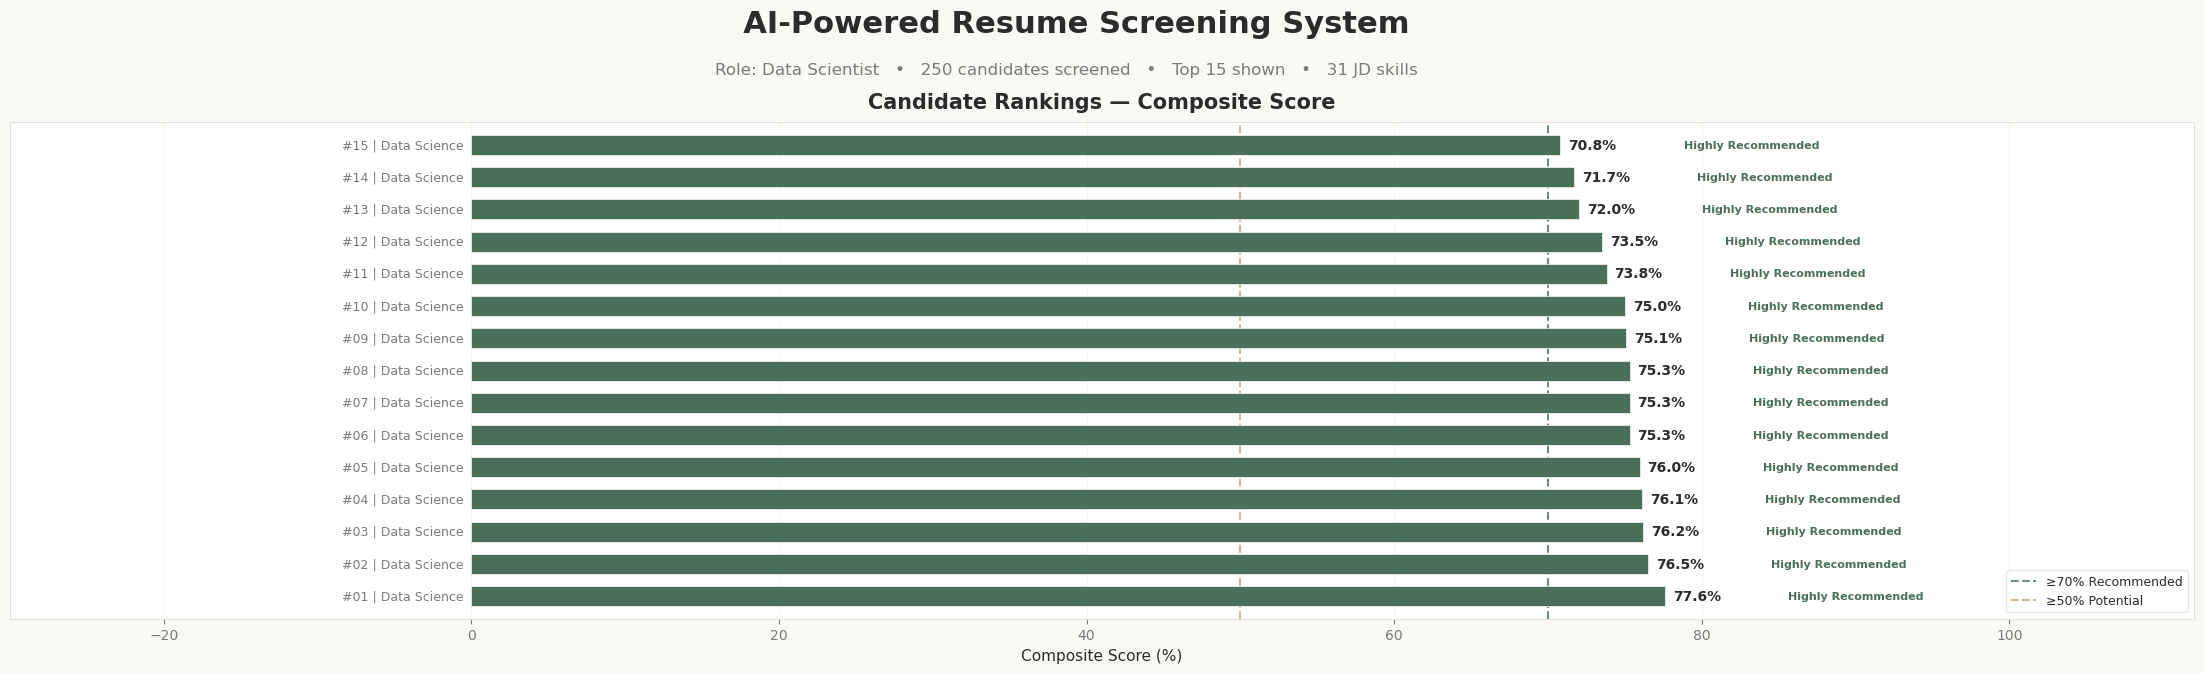

In [46]:
P = {
    "bg": "#FAF9F6",        # warm off-white (not pure white)
    "panel": "#FFFFFF",     # clean cards
    "border": "#E5E0D8",    # soft beige-gray border

    "green": "#4A6F5A",     # muted forest green
    "yellow": "#C2A878",    # sand/gold tone (very subtle)
    "red": "#9B4444",       # muted wine red

    "accent1": "#3E4C59",   # slate charcoal (primary accent)
    "accent2": "#7C6F64",   # warm gray-brown
    "accent3": "#A3B18A",   # desaturated sage

    "purple": "#6D597A",    # dusty purple
    "blue": "#546A7B",      # gray-blue (not bright)

    "text": "#2B2B2B",      # soft black
    "sub": "#7A7A7A"        # muted text
}

SC = {
    "Highly Recommended": "#4A6F5A",
    "Potential Fit": "#C2A878",
    "Not Recommended": "#9B4444"
}
def _st(s): return "Highly Recommended" if s>=70 else "Potential Fit" if s>=50 else "Not Recommended"

plt.rcParams.update({"font.family":"DejaVu Sans","text.color":P["text"],
    "axes.facecolor":P["panel"],"figure.facecolor":P["bg"],"axes.edgecolor":P["border"],
    "axes.labelcolor":P["text"],"xtick.color":P["sub"],"ytick.color":P["sub"],
    "grid.color":P["border"],"grid.alpha":0.4})

fig = plt.figure(figsize=(24, 30)); fig.patch.set_facecolor(P["bg"])
gs  = GridSpec(4, 3, figure=fig, hspace=0.48, wspace=0.32, top=0.94, bottom=0.04, left=0.06, right=0.97)
top15 = results_df.head(15).copy()

fig.text(0.5, 0.970, "  AI-Powered Resume Screening System",
         ha="center", fontsize=22, fontweight="bold", color=P["text"])
fig.text(0.5, 0.956,
         f"Role: {TARGET_ROLE}   •   {len(df_resume)} candidates screened   •   Top 15 shown   •   {len(pipeline.jd_skills)} JD skills",
         ha="center", fontsize=12, color=P["sub"])

# Panel 1: Ranking bar
ax1 = fig.add_subplot(gs[0, :]); ax1.set_facecolor(P["panel"])
labels_ = [f"#{int(r['rank']):02d} | {r['category'][:18]}" for _,r in top15.iterrows()]
scores_ = top15["composite_score"].tolist()
bars = ax1.barh(range(len(labels_)), scores_, color=[SC[_st(s)] for s in scores_],
                height=0.62, edgecolor=P["bg"], linewidth=0.5, zorder=3)
for i,(bar,s,(_,row)) in enumerate(zip(bars, scores_, top15.iterrows())):
    ax1.text(bar.get_width()+0.5, i, f"{s:.1f}%", va="center", fontsize=10, fontweight="bold", color=P["text"])
    ax1.text(-0.5, i, labels_[i], va="center", ha="right", fontsize=9, color=P["sub"])
    st = _st(s)
    ax1.text(bar.get_width()+8, i, st, va="center", fontsize=8, color=SC[st], fontweight="bold")
ax1.axvline(70, color=P["green"],  ls="--", lw=1.5, alpha=0.8, label="≥70% Recommended")
ax1.axvline(50, color=P["yellow"], ls="--", lw=1.5, alpha=0.8, label="≥50% Potential")
ax1.set_xlim(-30,112); ax1.set_ylim(-0.7, len(labels_)-0.3); ax1.set_yticks([])
ax1.set_xlabel("Composite Score (%)", fontsize=11)
ax1.set_title("Candidate Rankings — Composite Score", fontsize=15, fontweight="bold", color=P["text"], pad=10)
ax1.legend(loc="lower right", fontsize=9, facecolor=P["panel"], edgecolor=P["border"])
ax1.grid(axis="x", alpha=0.3, zorder=0)
plt.savefig("Candidate Rankings.png")
plt.show()


     

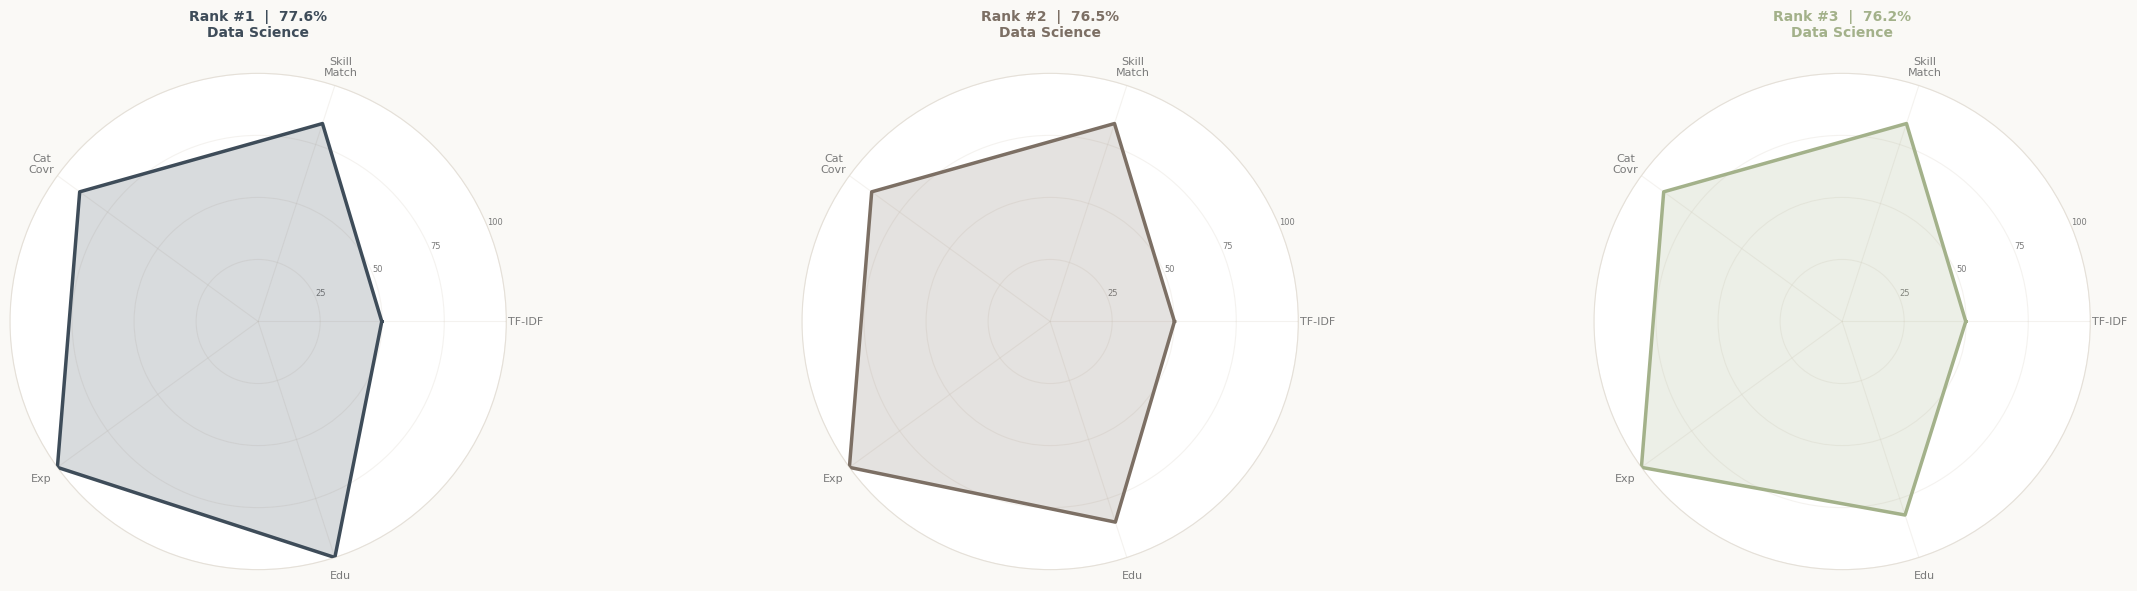

In [48]:
P = {
    "bg": "#FAF9F6",        # warm off-white (not pure white)
    "panel": "#FFFFFF",     # clean cards
    "border": "#E5E0D8",    # soft beige-gray border

    "green": "#4A6F5A",     # muted forest green
    "yellow": "#C2A878",    # sand/gold tone (very subtle)
    "red": "#9B4444",       # muted wine red

    "accent1": "#3E4C59",   # slate charcoal (primary accent)
    "accent2": "#7C6F64",   # warm gray-brown
    "accent3": "#A3B18A",   # desaturated sage

    "purple": "#6D597A",    # dusty purple
    "blue": "#546A7B",      # gray-blue (not bright)

    "text": "#2B2B2B",      # soft black
    "sub": "#7A7A7A"        # muted text
}

SC = {
    "Highly Recommended": "#4A6F5A",
    "Potential Fit": "#C2A878",
    "Not Recommended": "#9B4444"
}
def _st(s): return "Highly Recommended" if s>=70 else "Potential Fit" if s>=50 else "Not Recommended"

plt.rcParams.update({"font.family":"DejaVu Sans","text.color":P["text"],
    "axes.facecolor":P["panel"],"figure.facecolor":P["bg"],"axes.edgecolor":P["border"],
    "axes.labelcolor":P["text"],"xtick.color":P["sub"],"ytick.color":P["sub"],
    "grid.color":P["border"],"grid.alpha":0.4})

fig = plt.figure(figsize=(24, 30)); fig.patch.set_facecolor(P["bg"])
gs  = GridSpec(4, 3, figure=fig, hspace=0.48, wspace=0.32, top=0.94, bottom=0.04, left=0.06, right=0.97)
top15 = results_df.head(15).copy()

# Panel 2: Radar (top 3)
fk = ["tfidf_score","skill_match_pct","category_pct","exp_score","edu_score"]
fl = ["TF-IDF","Skill\nMatch","Cat\nCovr","Exp","Edu"]
angles = [n/5*2*math.pi for n in range(5)] + [0]
for ci,(_,c) in enumerate(top15.head(3).iterrows()):
    ax = fig.add_subplot(gs[1,ci], polar=True)
    ax.set_facecolor(P["panel"]); ax.spines["polar"].set_color(P["border"])
    vals = [c[k] for k in fk] + [c[fk[0]]]
    col  = [P["accent1"],P["accent2"],P["accent3"]][ci]
    ax.plot(angles, vals, color=col, lw=2.5, zorder=3); ax.fill(angles, vals, color=col, alpha=0.2, zorder=2)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(fl, size=8, color=P["sub"])
    ax.set_ylim(0,100); ax.set_yticks([25,50,75,100]); ax.set_yticklabels(["25","50","75","100"],size=6,color=P["sub"])
    ax.grid(color=P["border"], alpha=0.4)
    ax.set_title(f"Rank #{int(c['rank'])}  |  {c['composite_score']:.1f}%\n{c['category'][:22]}",
                 size=10, fontweight="bold", color=col, pad=14)

plt.savefig("Radar Rank.png")
plt.show()


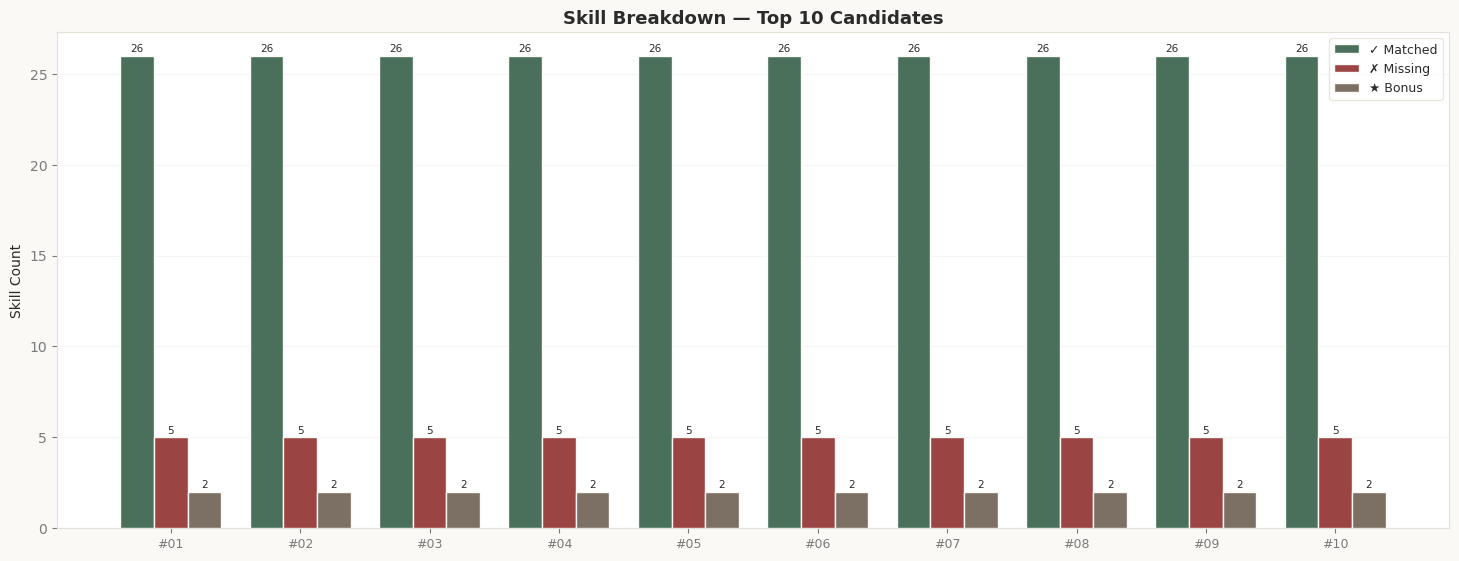

In [50]:
P = {
    "bg": "#FAF9F6",        # warm off-white (not pure white)
    "panel": "#FFFFFF",     # clean cards
    "border": "#E5E0D8",    # soft beige-gray border

    "green": "#4A6F5A",     # muted forest green
    "yellow": "#C2A878",    # sand/gold tone (very subtle)
    "red": "#9B4444",       # muted wine red

    "accent1": "#3E4C59",   # slate charcoal (primary accent)
    "accent2": "#7C6F64",   # warm gray-brown
    "accent3": "#A3B18A",   # desaturated sage

    "purple": "#6D597A",    # dusty purple
    "blue": "#546A7B",      # gray-blue (not bright)

    "text": "#2B2B2B",      # soft black
    "sub": "#7A7A7A"        # muted text
}

SC = {
    "Highly Recommended": "#4A6F5A",
    "Potential Fit": "#C2A878",
    "Not Recommended": "#9B4444"
}
def _st(s): return "Highly Recommended" if s>=70 else "Potential Fit" if s>=50 else "Not Recommended"

plt.rcParams.update({"font.family":"DejaVu Sans","text.color":P["text"],
    "axes.facecolor":P["panel"],"figure.facecolor":P["bg"],"axes.edgecolor":P["border"],
    "axes.labelcolor":P["text"],"xtick.color":P["sub"],"ytick.color":P["sub"],
    "grid.color":P["border"],"grid.alpha":0.4})

fig = plt.figure(figsize=(24, 30)); fig.patch.set_facecolor(P["bg"])
gs  = GridSpec(4, 3, figure=fig, hspace=0.48, wspace=0.32, top=0.94, bottom=0.04, left=0.06, right=0.97)
top15 = results_df.head(15).copy()

# Panel 3: Skill breakdown bar
ax3 = fig.add_subplot(gs[2,:2]); ax3.set_facecolor(P["panel"])
t10 = results_df.head(10)
ids_ = [f"#{int(r['rank']):02d}" for _,r in t10.iterrows()]
xv = np.arange(len(ids_)); w = 0.26
for offset,key,lbl,col in [(-w,"matched_skills","✓ Matched",P["green"]),
                             (0,"missing_skills","✗ Missing",P["red"]),
                             (w,"bonus_skills","★ Bonus",P["accent2"])]:
    vals = [len(r[key]) for _,r in t10.iterrows()]
    bs = ax3.bar(xv+offset, vals, w, label=lbl, color=col, edgecolor=P["bg"], zorder=3)
    for b in bs:
        h = b.get_height()
        if h>0: ax3.text(b.get_x()+b.get_width()/2, h+0.1, str(int(h)), ha="center", va="bottom", fontsize=7.5, color=P["text"])
ax3.set_xticks(xv); ax3.set_xticklabels(ids_, fontsize=9)
ax3.set_ylabel("Skill Count", fontsize=10)
ax3.set_title("Skill Breakdown — Top 10 Candidates", fontsize=13, fontweight="bold", color=P["text"])
ax3.legend(fontsize=9, facecolor=P["panel"], edgecolor=P["border"]); ax3.grid(axis="y", alpha=0.3, zorder=0)
plt.savefig("Skill Breakdown.png")
plt.show()

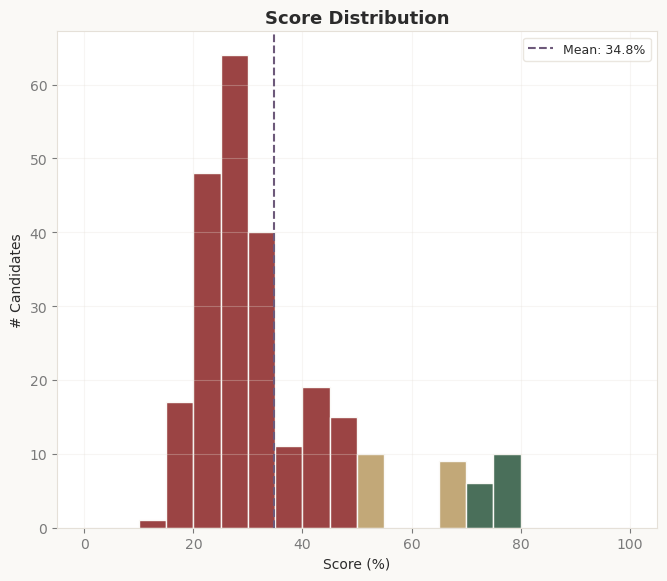

In [52]:
P = {
    "bg": "#FAF9F6",        # warm off-white (not pure white)
    "panel": "#FFFFFF",     # clean cards
    "border": "#E5E0D8",    # soft beige-gray border

    "green": "#4A6F5A",     # muted forest green
    "yellow": "#C2A878",    # sand/gold tone (very subtle)
    "red": "#9B4444",       # muted wine red

    "accent1": "#3E4C59",   # slate charcoal (primary accent)
    "accent2": "#7C6F64",   # warm gray-brown
    "accent3": "#A3B18A",   # desaturated sage

    "purple": "#6D597A",    # dusty purple
    "blue": "#546A7B",      # gray-blue (not bright)

    "text": "#2B2B2B",      # soft black
    "sub": "#7A7A7A"        # muted text
}

SC = {
    "Highly Recommended": "#4A6F5A",
    "Potential Fit": "#C2A878",
    "Not Recommended": "#9B4444"
}
def _st(s): return "Highly Recommended" if s>=70 else "Potential Fit" if s>=50 else "Not Recommended"

plt.rcParams.update({"font.family":"DejaVu Sans","text.color":P["text"],
    "axes.facecolor":P["panel"],"figure.facecolor":P["bg"],"axes.edgecolor":P["border"],
    "axes.labelcolor":P["text"],"xtick.color":P["sub"],"ytick.color":P["sub"],
    "grid.color":P["border"],"grid.alpha":0.4})

fig = plt.figure(figsize=(24, 30)); fig.patch.set_facecolor(P["bg"])
gs  = GridSpec(4, 3, figure=fig, hspace=0.48, wspace=0.32, top=0.94, bottom=0.04, left=0.06, right=0.97)
top15 = results_df.head(15).copy()

# Panel 4: Score distribution
ax4 = fig.add_subplot(gs[2,2]); ax4.set_facecolor(P["panel"])
bins = np.linspace(0,100,21)
_,_,patches = ax4.hist(results_df["composite_score"], bins=bins, edgecolor=P["bg"])
for patch in patches:
    mid = patch.get_x()+patch.get_width()/2
    patch.set_facecolor(P["green"] if mid>=70 else P["yellow"] if mid>=50 else P["red"])
ax4.axvline(results_df["composite_score"].mean(), color=P["purple"], ls="--", lw=1.5,
            label=f"Mean: {results_df['composite_score'].mean():.1f}%")
ax4.set_xlabel("Score (%)", fontsize=10); ax4.set_ylabel("# Candidates", fontsize=10)
ax4.set_title("Score Distribution", fontsize=13, fontweight="bold", color=P["text"])
ax4.legend(fontsize=9, facecolor=P["panel"], edgecolor=P["border"]); ax4.grid(alpha=0.3)
plt.savefig("Score Distribution.png")
plt.show()

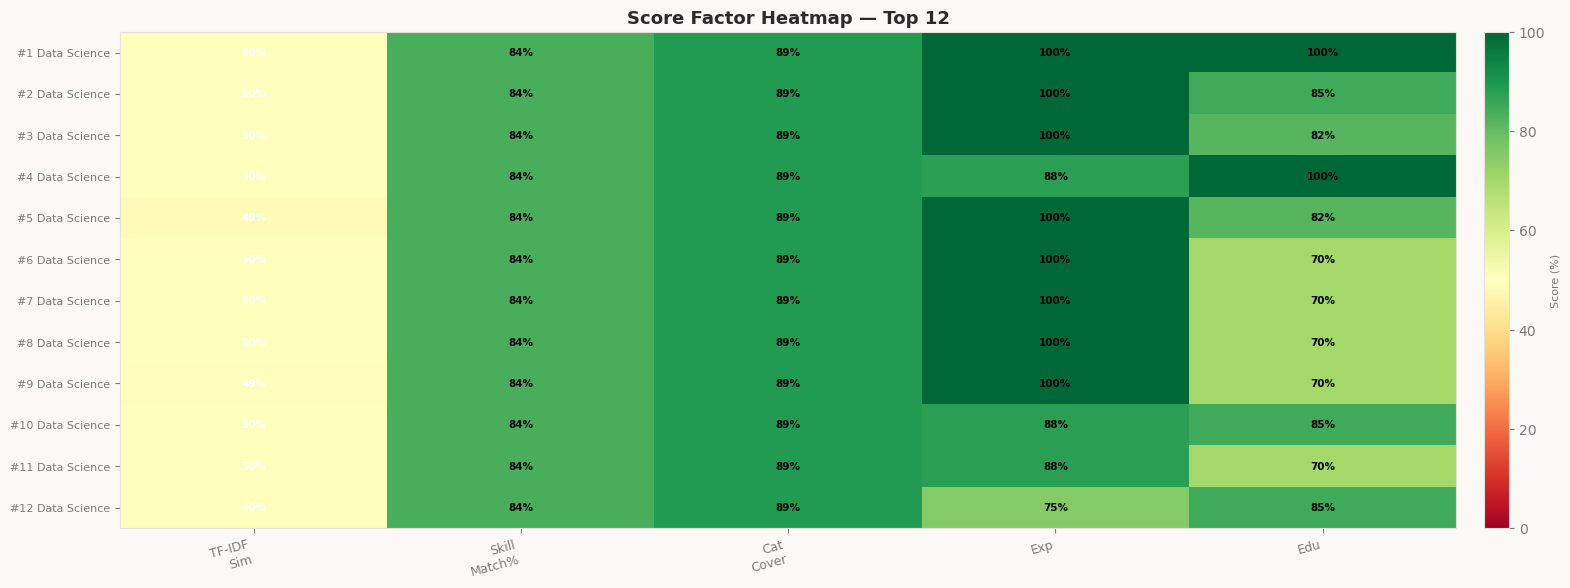

In [54]:
P = {
    "bg": "#FAF9F6",        # warm off-white (not pure white)
    "panel": "#FFFFFF",     # clean cards
    "border": "#E5E0D8",    # soft beige-gray border

    "green": "#4A6F5A",     # muted forest green
    "yellow": "#C2A878",    # sand/gold tone (very subtle)
    "red": "#9B4444",       # muted wine red

    "accent1": "#3E4C59",   # slate charcoal (primary accent)
    "accent2": "#7C6F64",   # warm gray-brown
    "accent3": "#A3B18A",   # desaturated sage

    "purple": "#6D597A",    # dusty purple
    "blue": "#546A7B",      # gray-blue (not bright)

    "text": "#2B2B2B",      # soft black
    "sub": "#7A7A7A"        # muted text
}

SC = {
    "Highly Recommended": "#4A6F5A",
    "Potential Fit": "#C2A878",
    "Not Recommended": "#9B4444"
}
def _st(s): return "Highly Recommended" if s>=70 else "Potential Fit" if s>=50 else "Not Recommended"

plt.rcParams.update({"font.family":"DejaVu Sans","text.color":P["text"],
    "axes.facecolor":P["panel"],"figure.facecolor":P["bg"],"axes.edgecolor":P["border"],
    "axes.labelcolor":P["text"],"xtick.color":P["sub"],"ytick.color":P["sub"],
    "grid.color":P["border"],"grid.alpha":0.4})

fig = plt.figure(figsize=(24, 30)); fig.patch.set_facecolor(P["bg"])
gs  = GridSpec(4, 3, figure=fig, hspace=0.48, wspace=0.32, top=0.94, bottom=0.04, left=0.06, right=0.97)
top15 = results_df.head(15).copy()
# Panel 5: Heatmap
ax5 = fig.add_subplot(gs[3,:2]); ax5.set_facecolor(P["panel"])
t12 = results_df.head(12)
heat = np.array([[r["tfidf_score"],r["skill_match_pct"],r["category_pct"],r["exp_score"],r["edu_score"]] for _,r in t12.iterrows()])
im = ax5.imshow(heat, cmap="RdYlGn", aspect="auto", vmin=0, vmax=100)
ax5.set_xticks(range(5)); ax5.set_xticklabels(["TF-IDF\nSim","Skill\nMatch%","Cat\nCover","Exp","Edu"],fontsize=9,rotation=15,ha="right")
ax5.set_yticks(range(12)); ax5.set_yticklabels([f"#{int(r['rank'])} {r['category'][:14]}" for _,r in t12.iterrows()], fontsize=8)
for i in range(12):
    for j in range(5):
        v=heat[i,j]; ax5.text(j,i,f"{v:.0f}%",ha="center",va="center",fontsize=7.5,fontweight="bold",color="black" if v>55 else "white")
cbar=plt.colorbar(im,ax=ax5,fraction=0.02,pad=0.02); cbar.set_label("Score (%)",color=P["sub"],fontsize=8)
cbar.ax.yaxis.set_tick_params(color=P["sub"]); plt.setp(cbar.ax.yaxis.get_ticklabels(),color=P["sub"])
ax5.set_title("Score Factor Heatmap — Top 12", fontsize=13, fontweight="bold", color=P["text"])
plt.savefig("Heatmap.png")
plt.show()

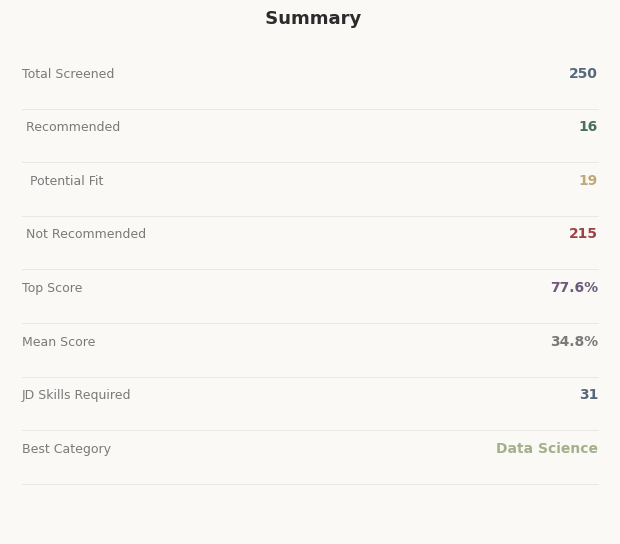

In [56]:
P = {
    "bg": "#FAF9F6",        # warm off-white (not pure white)
    "panel": "#FFFFFF",     # clean cards
    "border": "#E5E0D8",    # soft beige-gray border

    "green": "#4A6F5A",     # muted forest green
    "yellow": "#C2A878",    # sand/gold tone (very subtle)
    "red": "#9B4444",       # muted wine red

    "accent1": "#3E4C59",   # slate charcoal (primary accent)
    "accent2": "#7C6F64",   # warm gray-brown
    "accent3": "#A3B18A",   # desaturated sage

    "purple": "#6D597A",    # dusty purple
    "blue": "#546A7B",      # gray-blue (not bright)

    "text": "#2B2B2B",      # soft black
    "sub": "#7A7A7A"        # muted text
}

SC = {
    "Highly Recommended": "#4A6F5A",
    "Potential Fit": "#C2A878",
    "Not Recommended": "#9B4444"
}
def _st(s): return "Highly Recommended" if s>=70 else "Potential Fit" if s>=50 else "Not Recommended"

plt.rcParams.update({"font.family":"DejaVu Sans","text.color":P["text"],
    "axes.facecolor":P["panel"],"figure.facecolor":P["bg"],"axes.edgecolor":P["border"],
    "axes.labelcolor":P["text"],"xtick.color":P["sub"],"ytick.color":P["sub"],
    "grid.color":P["border"],"grid.alpha":0.4})

fig = plt.figure(figsize=(24, 30)); fig.patch.set_facecolor(P["bg"])
gs  = GridSpec(4, 3, figure=fig, hspace=0.48, wspace=0.32, top=0.94, bottom=0.04, left=0.06, right=0.97)
top15 = results_df.head(15).copy()

# Panel 6: Summary cards
ax6 = fig.add_subplot(gs[3,2]); ax6.set_facecolor(P["panel"]); ax6.axis("off")
rec_=(results_df["composite_score"]>=70).sum(); pot_=((results_df["composite_score"]>=50)&(results_df["composite_score"]<70)).sum()
stats=[("Total Screened",str(len(results_df)),P["blue"]),(" Recommended",str(rec_),P["green"]),
       ("  Potential Fit",str(pot_),P["yellow"]),(" Not Recommended",str((results_df["composite_score"]<50).sum()),P["red"]),
       ("Top Score",f"{results_df['composite_score'].max():.1f}%",P["purple"]),
       ("Mean Score",f"{results_df['composite_score'].mean():.1f}%",P["sub"]),
       ("JD Skills Required",str(len(pipeline.jd_skills)),P["blue"]),
       ("Best Category",results_df.iloc[0]["category"][:18],P["accent3"])]
ax6.set_title(" Summary", fontsize=13, fontweight="bold", color=P["text"], pad=10)
y=0.92
for lbl,val,col in stats:
    ax6.text(0.02,y,lbl,transform=ax6.transAxes,fontsize=9,color=P["sub"])
    ax6.text(0.98,y,val,transform=ax6.transAxes,fontsize=10,fontweight="bold",color=col,ha="right")
    y-=0.108
    ax6.plot([0.02,0.98],[y+0.045,y+0.045],color=P["border"],linewidth=0.5,transform=ax6.transAxes,clip_on=False)
plt.savefig("Summary.png")
plt.show()

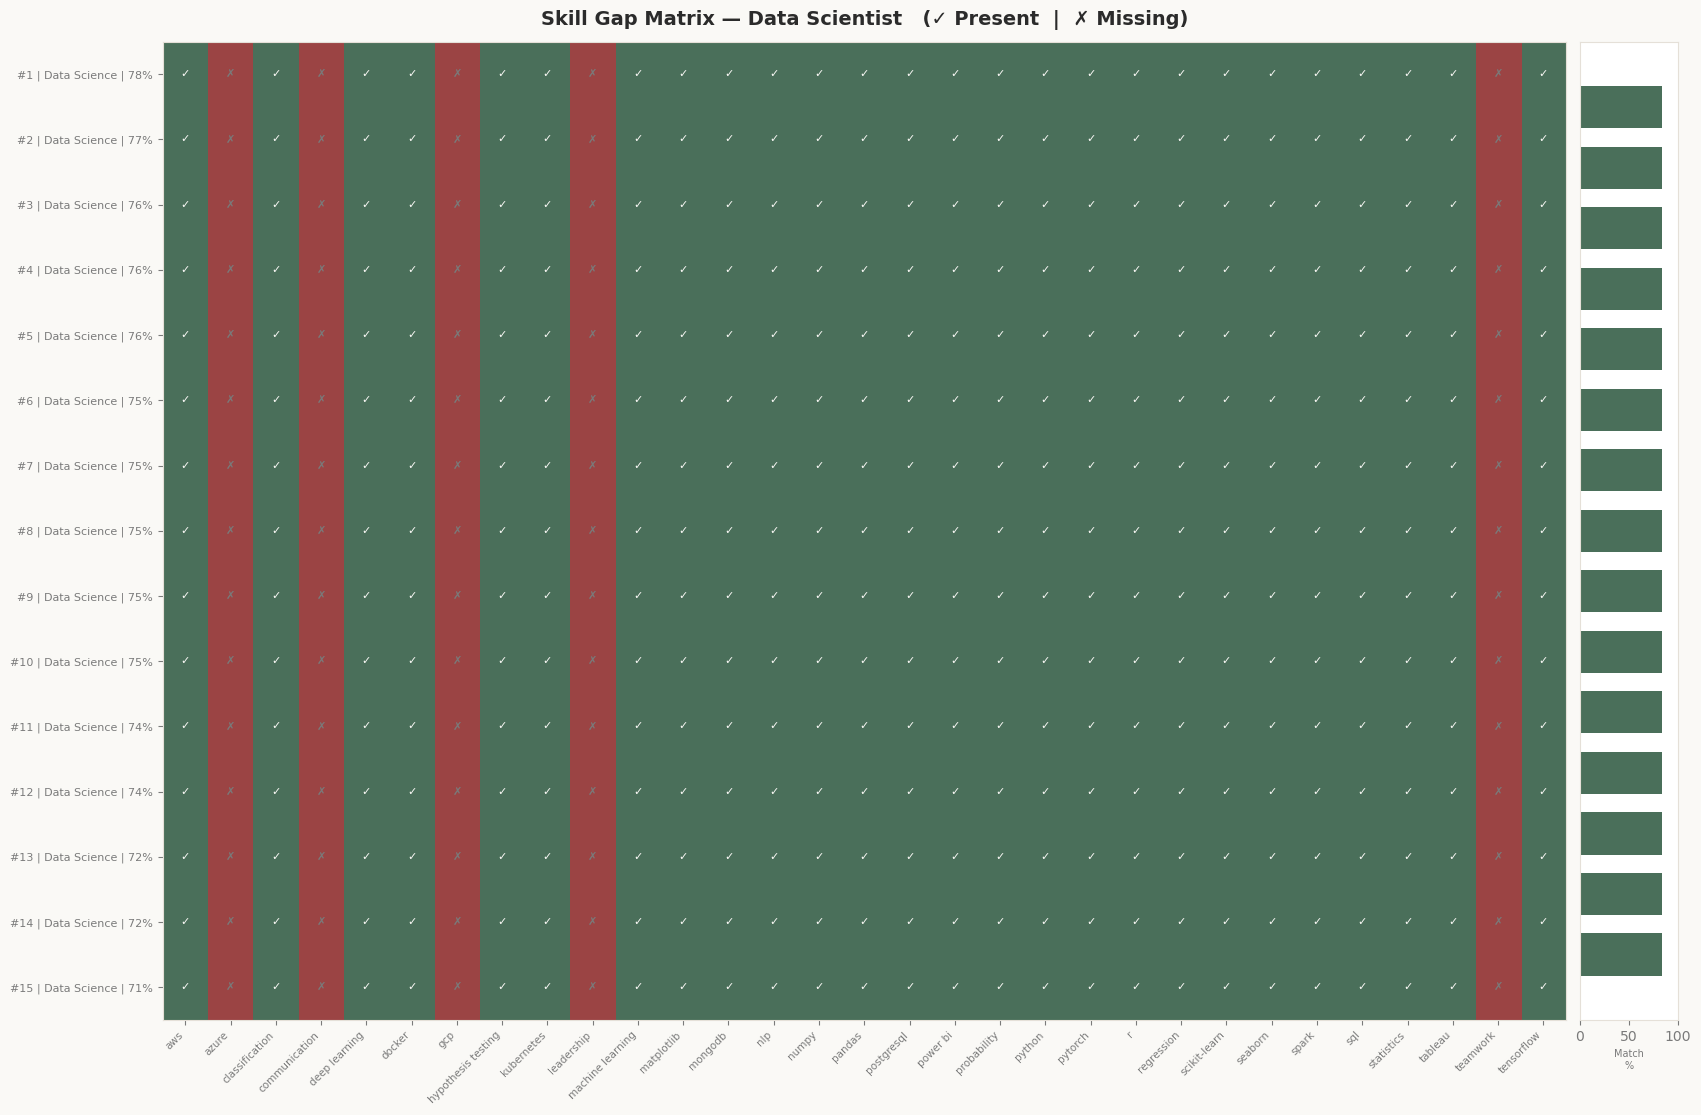

 Skill gap heatmap saved → skill_gap_heatmap.png


In [58]:
TOP_N_GAP = min(15, len(results_df))
top_gap   = results_df.head(TOP_N_GAP)
req_list  = sorted(pipeline.jd_skills.keys())

matrix = np.zeros((TOP_N_GAP, len(req_list)))
for i,(_,row) in enumerate(top_gap.iterrows()):
    ms = set(row["matched_skills"]) if isinstance(row["matched_skills"], list) else set()
    for j,sk in enumerate(req_list):
        matrix[i,j] = 1 if sk in ms else 0

fig, ax = plt.subplots(figsize=(max(16, len(req_list)*0.55), max(8, TOP_N_GAP*0.55+3)))
fig.patch.set_facecolor(P["bg"]); ax.set_facecolor(P["panel"])

cmap_gap = mcolors.LinearSegmentedColormap.from_list("gap",[P["red"],P["panel"],P["green"]])
ax.imshow(matrix, cmap=cmap_gap, aspect="auto", vmin=0, vmax=1)
for i in range(TOP_N_GAP):
    for j in range(len(req_list)):
        sym="✓" if matrix[i,j]==1 else "✗"
        ax.text(j,i,sym,ha="center",va="center",fontsize=8,
                color=P["bg"] if matrix[i,j]==1 else P["sub"],fontweight="bold")

ax.set_xticks(range(len(req_list)))
ax.set_xticklabels(req_list, rotation=45, ha="right", fontsize=7.5, color=P["sub"])
ax.set_yticks(range(TOP_N_GAP))
ax.set_yticklabels([f"#{int(r['rank'])} | {r['category'][:16]} | {r['composite_score']:.0f}%"
                    for _,r in top_gap.iterrows()], fontsize=8)
ax.set_title(f"Skill Gap Matrix — {TARGET_ROLE}   (✓ Present  |  ✗ Missing)",
             fontsize=14, fontweight="bold", color=P["text"], pad=12)

ax_r = ax.inset_axes([1.01,0,0.07,1])
cov = matrix.mean(axis=1)*100
ax_r.barh(range(TOP_N_GAP), cov,
          color=[P["green"] if c>=70 else P["yellow"] if c>=50 else P["red"] for c in cov], height=0.7)
ax_r.set_xlim(0,100); ax_r.set_yticks([]); ax_r.set_xlabel("Match\n%",fontsize=7,color=P["sub"])
ax_r.set_facecolor(P["panel"])
for sp in ax_r.spines.values(): sp.set_color(P["border"])
ax_r.tick_params(colors=P["sub"])

plt.tight_layout()
plt.savefig("skill_gap_heatmap.png", dpi=140, bbox_inches="tight", facecolor=P["bg"])
plt.show()
print(" Skill gap heatmap saved → skill_gap_heatmap.png")

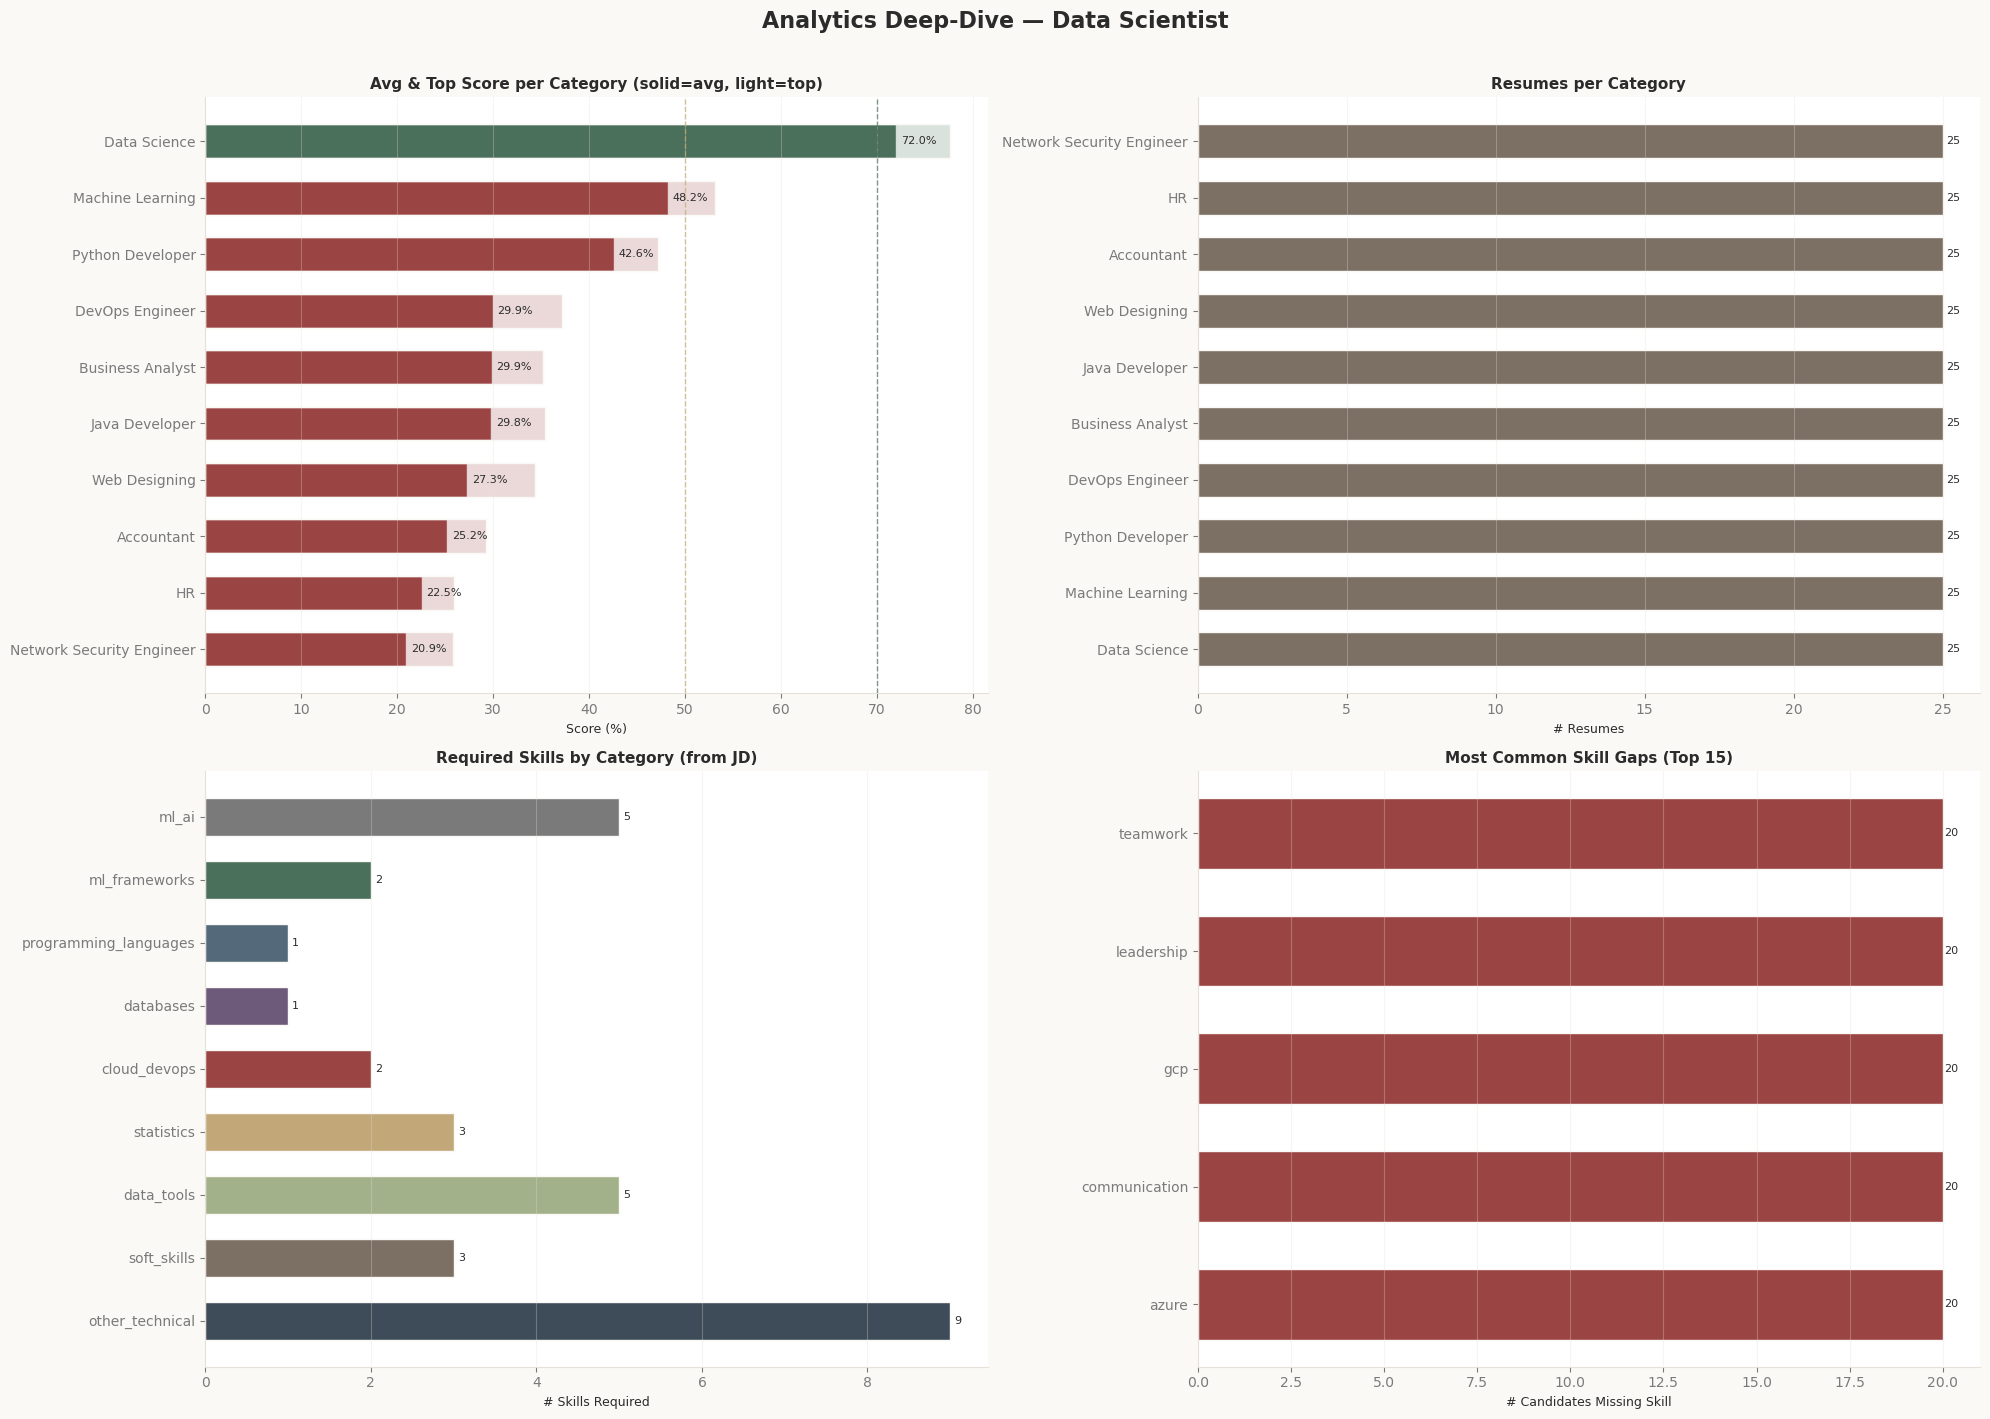

 Analytics chart saved → analytics_deep_dive.png


In [60]:

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.patch.set_facecolor(P["bg"])
fig.suptitle(f"Analytics Deep-Dive — {TARGET_ROLE}", fontsize=16, fontweight="bold", color=P["text"], y=1.01)

# (0,0) Category avg score
ax = axes[0][0]; ax.set_facecolor(P["panel"])
cs = cat_lb.sort_values("avg_score", ascending=True)
bcs = [P["green"] if s>=70 else P["yellow"] if s>=50 else P["red"] for s in cs["avg_score"]]
ax.barh(cs.index, cs["avg_score"],   color=bcs,           height=0.6, edgecolor=P["bg"])
ax.barh(cs.index, cs["top_score"],   color=[c+"33" for c in bcs], height=0.6, edgecolor=P["bg"])
for _,(cat,row) in enumerate(cs.iterrows()):
    ax.text(row["avg_score"]+0.5, cat, f"{row['avg_score']:.1f}%", va="center", fontsize=8, color=P["text"])
ax.axvline(50,color=P["yellow"],ls="--",lw=1,alpha=0.7); ax.axvline(70,color=P["green"],ls="--",lw=1,alpha=0.7)
ax.set_xlabel("Score (%)", fontsize=9); ax.grid(axis="x", alpha=0.3)
ax.set_title("Avg & Top Score per Category (solid=avg, light=top)", fontsize=11, fontweight="bold", color=P["text"])

# (0,1) Resumes per category
ax = axes[0][1]; ax.set_facecolor(P["panel"])
cn = cat_lb.sort_values("n_resumes", ascending=True)
ax.barh(cn.index, cn["n_resumes"], color=P["accent2"], height=0.6, edgecolor=P["bg"])
for _,(cat,row) in enumerate(cn.iterrows()):
    ax.text(row["n_resumes"]+0.1, cat, str(int(row["n_resumes"])), va="center", fontsize=8, color=P["text"])
ax.set_xlabel("# Resumes", fontsize=9); ax.grid(axis="x", alpha=0.3)
ax.set_title("Resumes per Category", fontsize=11, fontweight="bold", color=P["text"])

# (1,0) JD skill category breakdown
ax = axes[1][0]; ax.set_facecolor(P["panel"])
cc = Counter(pipeline.jd_skills.values())
pie_cols=[P["accent1"],P["accent2"],P["accent3"],P["yellow"],P["red"],P["purple"],P["blue"],P["green"],P["sub"]]
ax.barh(list(cc.keys()), list(cc.values()), color=pie_cols[:len(cc)], height=0.6, edgecolor=P["bg"])
for c,f in cc.items():
    ax.text(f+0.05, c, str(f), va="center", fontsize=8, color=P["text"])
ax.set_xlabel("# Skills Required", fontsize=9); ax.grid(axis="x", alpha=0.3)
ax.set_title("Required Skills by Category (from JD)", fontsize=11, fontweight="bold", color=P["text"])

# (1,1) Top skill gaps
ax = axes[1][1]; ax.set_facecolor(P["panel"])
tg = gap_df.head(15)
ax.barh(tg["skill"], tg["frequency"], color=P["red"], height=0.6, edgecolor=P["bg"])
for _,row in tg.iterrows():
    ax.text(row["frequency"]+0.05, row["skill"], str(int(row["frequency"])), va="center", fontsize=8, color=P["text"])
ax.set_xlabel("# Candidates Missing Skill", fontsize=9); ax.grid(axis="x", alpha=0.3)
ax.set_title("Most Common Skill Gaps (Top 15)", fontsize=11, fontweight="bold", color=P["text"])

for a in axes.flat: a.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("analytics_deep_dive.png", dpi=140, bbox_inches="tight", facecolor=P["bg"])
plt.show()
print(" Analytics chart saved → analytics_deep_dive.png")


   Role     : Data Scientist
   JD Skills: 31 across 9 categories
  Resumes  : 250 to screen

    Screening 250 resumes...
   Done!  Top: 77.6% |  16  ⚠️ 19   215

   Role     : Machine Learning Engineer
   JD Skills: 18 across 5 categories
  Resumes  : 250 to screen

    Screening 250 resumes...
   Done!  Top: 76.3% |  16  ⚠️ 28   206

   Role     : Full Stack Developer
   JD Skills: 20 across 6 categories
  Resumes  : 250 to screen

    Screening 250 resumes...
   Done!  Top: 73.2% |  7  ⚠️ 38   205

   Role     : DevOps Engineer
   JD Skills: 11 across 3 categories
  Resumes  : 250 to screen

    Screening 250 resumes...
   Done!  Top: 65.9% |  0  ⚠️ 58   192

   Role     : Data Analyst
   JD Skills: 16 across 7 categories
  Resumes  : 250 to screen

    Screening 250 resumes...
   Done!  Top: 66.2% |  0  ⚠️ 25   225

   Role     : Software Engineer
   JD Skills: 12 across 4 categories
  Resumes  : 250 to screen

    Screening 250 resumes...
   Done!  Top: 63.9% |  0  ⚠️ 99   151


,Role,Top Score,Mean Score,Std Dev,Recommended,Potential,JD Skills
5,Software Engineer,63.910000,43.480000,12.400000,0,99,12
3,DevOps Engineer,65.880000,41.110000,10.330000,0,58,11
2,Full Stack Developer,73.160000,37.150000,14.360000,7,38,20
1,Machine Learning Engineer,76.260000,36.740000,15.260000,16,28,18
0,Data Scientist,77.630000,34.840000,15.270000,16,19,31
4,Data Analyst,66.200000,33.390000,11.790000,0,25,16


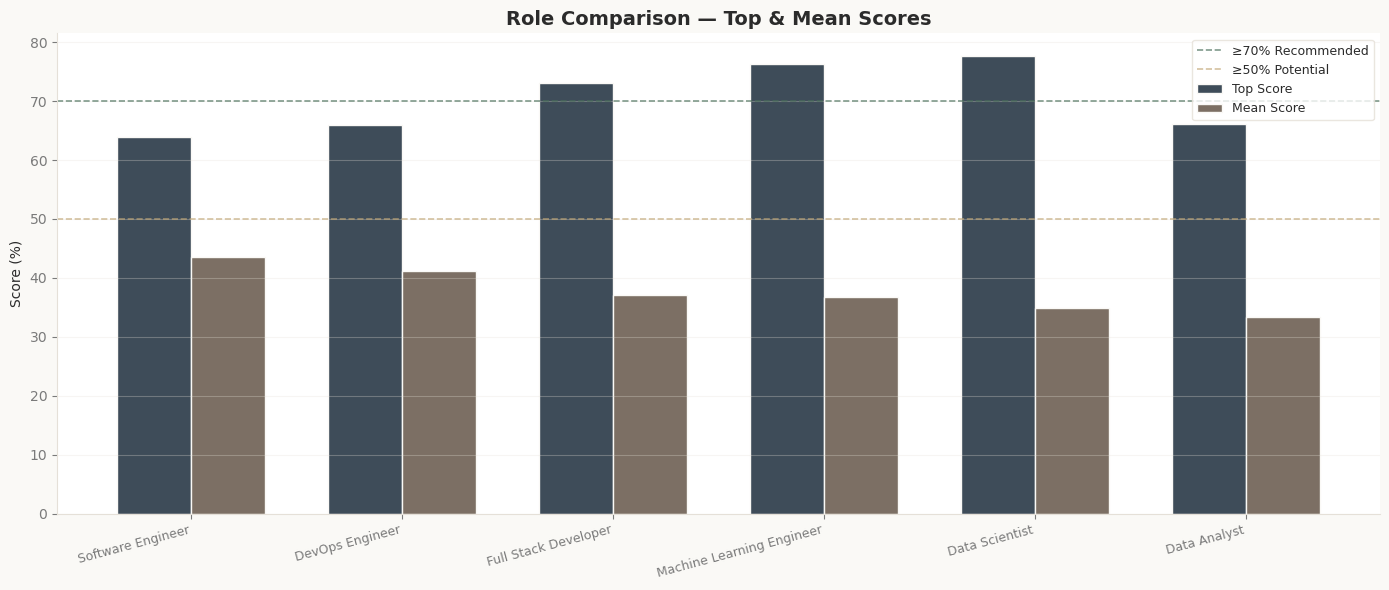

 Role comparison chart saved → role_comparison.png


In [62]:
comparison_rows = []
for role in df_jd["Job Title"].dropna().unique()[:6]:
    try:
        p = ResumeScreeningPipeline(role, df_jd, df_resume)
        r = p.run()
        comparison_rows.append({"Role": role,
            "Top Score": r["composite_score"].max(),
            "Mean Score": round(r["composite_score"].mean(), 2),
            "Std Dev": round(r["composite_score"].std(), 2),
            " Recommended": (r["composite_score"]>=70).sum(),
            " Potential": ((r["composite_score"]>=50)&(r["composite_score"]<70)).sum(),
            "JD Skills": len(p.jd_skills)})
    except Exception as e: print(f"Skipping '{role}': {e}")

cmp_df = pd.DataFrame(comparison_rows).sort_values("Mean Score", ascending=False)
display(cmp_df.style.background_gradient(subset=["Mean Score","Top Score"], cmap="RdYlGn"))

fig, ax = plt.subplots(figsize=(14, 6)); fig.patch.set_facecolor(P["bg"]); ax.set_facecolor(P["panel"])
x = np.arange(len(cmp_df)); w = 0.35
ax.bar(x-w/2, cmp_df["Top Score"],  w, label="Top Score",  color=P["accent1"], edgecolor=P["bg"])
ax.bar(x+w/2, cmp_df["Mean Score"], w, label="Mean Score", color=P["accent2"], edgecolor=P["bg"])
ax.set_xticks(x); ax.set_xticklabels(cmp_df["Role"], rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Score (%)", fontsize=10)
ax.set_title("Role Comparison — Top & Mean Scores", fontsize=14, fontweight="bold", color=P["text"])
ax.axhline(70, color=P["green"],  ls="--", lw=1.2, alpha=0.7, label="≥70% Recommended")
ax.axhline(50, color=P["yellow"], ls="--", lw=1.2, alpha=0.7, label="≥50% Potential")
ax.legend(fontsize=9, facecolor=P["panel"], edgecolor=P["border"])
ax.grid(axis="y", alpha=0.3); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("role_comparison.png", dpi=140, bbox_inches="tight", facecolor=P["bg"])
plt.show()
print(" Role comparison chart saved → role_comparison.png")

In [68]:
# Export results to CSV
csv_name = TARGET_ROLE.replace(" ", "_") + "_screening_results.csv"

results_df[[
    "rank","resume_id","category","composite_score","status",
    "est_years_exp","tfidf_score","skill_match_pct","category_pct",
    "exp_score","edu_score","total_skills","matched_skills",
    "missing_skills","bonus_skills","snippet"
]].to_csv(csv_name, index=False)

print(f" Results exported → {csv_name} ({len(results_df)} rows)")


# ✅ Save plots (instead of auto-download)
import os

files_to_check = [
    csv_name,
    "recruiter_dashboard.png",
    "skill_gap_heatmap.png",
    "analytics_deep_dive.png",
    "role_comparison.png"
]


# ✅ Final Summary
print("\n" + "="*65)
print("    ALL DONE!")
print("="*65)

print(f"  Role           : {TARGET_ROLE}")
print(f"  Total Screened : {len(results_df)}")

recommended = (results_df['composite_score'] >= 70).sum()
potential    = ((results_df['composite_score'] >= 50) & (results_df['composite_score'] < 70)).sum()
not_rec      = (results_df['composite_score'] < 50).sum()

print(f"  Recommended    : {recommended}")
print(f"  Potential Fit  : {potential}")
print(f"  Not Recommended: {not_rec}")

print(f"  Top Score      : {results_df['composite_score'].max():.1f}%")
print(f"  Mean Score     : {results_df['composite_score'].mean():.1f}%")

print("="*65)

 Results exported → Data_Scientist_screening_results.csv (250 rows)

    ALL DONE!
  Role           : Data Scientist
  Total Screened : 250
  Recommended    : 16
  Potential Fit  : 19
  Not Recommended: 215
  Top Score      : 77.6%
  Mean Score     : 34.8%
